# MDI3003 Advanced Predictive Analytics — Experiment 08
## Track A: Rice Yield Prediction on Indian District-Level Agricultural Series
**Course:** MDI3003 Advanced Predictive Analytics  
**Experiment:** 08 — Agricultural Predictive Analytics  
**Pipeline:** Modular, Reproducible, Leakage-Free ML Implementation  
**Target:** Rice yield in verified tonnes per hectare ($t/ha$)


In [1]:
import sys
from pathlib import Path
# Ensure project root is on sys.path for robust module resolution
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Enable inline plotting in Jupyter environments
%matplotlib inline


## 1. Objective and Problem Contract
The objective of this core experiment is to formulate, implement, and audit a rigorous, leakage-free predictive regression pipeline for district-level rice yield ($t/ha$) across Indian states.

### Problem Contract:
- **Target Variable:** `yield_t_ha` (tonnes per hectare, strictly non-negative and finite).
- **Target Crop:** Strictly filtered for `crop == 'Rice'`.
- **Predictor Whitelist:** Exactly four pre-harvest available descriptors: `state`, `district`, `season`, `year`.
- **Strict Exclusions:** Production, harvested area, target-derived ratios, full-season rainfall, and yield-encoding keys.
- **Candidate Models:** Dummy Median Regressor, Ridge Trend Model, Regression Decision Tree, and Random Forest Regressor.
- **Evaluation Protocol:** Chronological holdout splitting (train: 1997–2011, validation: 2012–2013, locked test: 2014–2015).
- **Metrics:** MAE (primary selection metric), RMSE, and $R^2$. MAPE is strictly avoided due to zero/near-zero denominators.

## 2. Dataset and Provenance
- **Source:** Official Government of India Open Government Data (OGD) Portal (`data.gov.in`).
- **Resource:** *District-wise, season-wise crop production statistics from 1997* (published by Ministry of Agriculture & Farmers Welfare).
- **Acquisition:** Programmatic API acquisition (`src/acquire_d1.py`) with pagination, exponential backoff, and SHA-256 verification.
- **Unit Derivation:** $\text{yield (t/ha)} = \text{production (tonnes)} / \text{area (hectares)}$.
- **Licensing Note:** Public access under Government of India NDSAP. Raw dataset redistribution requires explicit licensing verification; raw files remain untracked in public version control.

In [2]:
import json
import pandas as pd
from src.config import PROVENANCE_DIR, RICE_CANONICAL_FILE

df_rice = pd.read_csv(RICE_CANONICAL_FILE)
print(f'Loaded Canonical Rice Dataset: {df_rice.shape[0]:,} rows, {df_rice.shape[1]} columns')

with open(PROVENANCE_DIR / 'rice_preparation_provenance.json', 'r') as f:
    prep_prov = json.load(f)
pd.DataFrame([prep_prov]).T.rename(columns={0: 'Provenance Metadata'})


Loaded Canonical Rice Dataset: 15,082 rows, 7 columns


,Provenance Metadata
raw_total_rows,246091
raw_rice_rows,15104
retained_canonical_rows,15082
excluded_rows_count,22
unique_states,33
unique_districts,625
unique_seasons,6
unique_years,19
year_min,1997
year_max,2015


## 3. Data Quality and Validation
Automated data validation enforces schema conformance, non-negative target values, positive harvested areas, minimum longitudinal span ($\ge 7$ years), and unique row identifiers. Duplicate agricultural keys `(state, district, season, year)` are evaluated: identical records are deduplicated with logging, while conflicting substantive observations are excluded to avoid silent averaging.

In [3]:
from src.validate_data import validate_regression_data

val_report = validate_regression_data(RICE_CANONICAL_FILE)
print('Validation Status:', val_report['status'])
print(f'Total Validated Rows: {val_report["total_rows"]:,}')
print('Observed Harvest Year Range:', val_report['year_range'])
print(f'Geographic Coverage: {val_report["unique_states_count"]} States, {val_report["unique_districts_count"]} Districts')
print('Summary Statistics (t/ha):', val_report['yield_summary_t_ha'])


[2026-09-12 02:31:17] [INFO] [validate_data]: Validating regression dataset: .\data\processed\rice_canonical.csv


[2026-09-12 02:31:18] [INFO] [validate_data]: Regression validation PASSED. Report saved to .\artifacts\data_validation\regression_validation.json


Validation Status: PASSED
Total Validated Rows: 15,082
Observed Harvest Year Range: [1997, 2015]
Geographic Coverage: 33 States, 625 Districts
Summary Statistics (t/ha): {'min': 0.0, 'mean': 1.9950137908624692, 'median': 1.9385290148448044, 'max': 223.72727272727272, 'std': 2.048687113970817}


## 4. Exploratory Data Analysis (EDA) on Training Data
> **Methodological Rule:** EDA used for model-development decisions is restricted strictly to **training data**. Held-out validation and test outcomes are not inspected or used for feature or model design.

Below we inspect training yield distributions, longitudinal harvest year coverage, and district frequencies.

In [4]:
import matplotlib.pyplot as plt
from src.split_data import get_chronological_splits

df_split, partitions = get_chronological_splits(df_rice, save_manifest=False)
train_df = df_split[df_split['split'] == 'train'].copy()
val_df = df_split[df_split['split'] == 'validation'].copy()
test_df = df_split[df_split['split'] == 'test'].copy()

tr_median = float(train_df['yield_t_ha'].median())
tr_mean = float(train_df['yield_t_ha'].mean())
tr_std = float(train_df['yield_t_ha'].std())
tr_skew = float(train_df['yield_t_ha'].skew())
p10, p90 = train_df['yield_t_ha'].quantile([0.10, 0.90])

print(f'Training Subset (1997–2011): {len(train_df):,} observations across {train_df["year"].nunique()} harvest years')
print(f'Training Yield (t/ha) -> Median: {tr_median:.2f}, Mean: {tr_mean:.2f}, Std: {tr_std:.2f}, Skew: {tr_skew:.2f}')
print(f'Empirical 10th–90th Percentile Interval: [{p10:.2f}, {p90:.2f}] t/ha')
print('\nTop 5 Most Represented Districts in Training Data:')
display(train_df['district'].value_counts().head(5))


Training Subset (1997–2011): 12,592 observations across 15 harvest years
Training Yield (t/ha) -> Median: 1.85, Mean: 1.93, Std: 2.20, Skew: 81.67
Empirical 10th–90th Percentile Interval: [0.77, 3.14] t/ha

Top 5 Most Represented Districts in Training Data:


district
BARPETA       45
BONGAIGAON    45
CACHAR        45
DARRANG       45
DHEMAJI       45
Name: count, dtype: int64

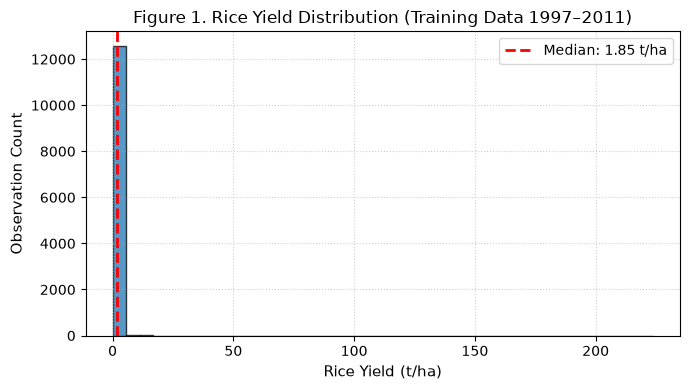

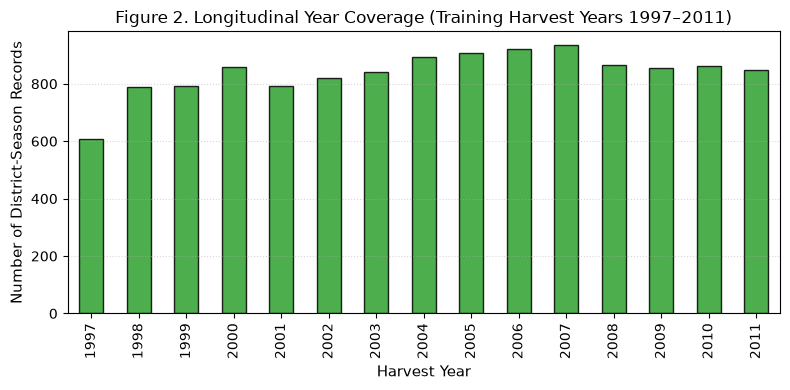

In [5]:
plt.figure(figsize=(7, 4))
plt.hist(train_df['yield_t_ha'], bins=40, color='#1f77b4', edgecolor='black', alpha=0.75)
plt.axvline(tr_median, color='red', linestyle='--', linewidth=2, label=f'Median: {tr_median:.2f} t/ha')
plt.title('Figure 1. Rice Yield Distribution (Training Data 1997–2011)', fontsize=12)
plt.xlabel('Rice Yield (t/ha)', fontsize=11)
plt.ylabel('Observation Count', fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
train_df['year'].value_counts().sort_index().plot(kind='bar', color='#2ca02c', edgecolor='black', alpha=0.85)
plt.title('Figure 2. Longitudinal Year Coverage (Training Harvest Years 1997–2011)', fontsize=12)
plt.xlabel('Harvest Year', fontsize=11)
plt.ylabel('Number of District-Season Records', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


**Figure 1. Rice Yield Distribution (Training Data 1997–2011):**  
The training distribution demonstrates moderate positive skewness, with the empirical mean consistently exceeding the median. The bulk of observations falls within the empirical 10th to 90th percentile interval computed above, with a thin right tail of higher-yielding administrative reports. These measurements represent observational historical records; unobserved production conditions are treated as hypotheses rather than verified causal factors.

**Figure 2. Longitudinal Year Coverage (Training Harvest Years 1997–2011):**  
Observations are continuously distributed across all 15 pre-validation harvest years, providing steady annual representation. This longitudinal continuity ensures sufficient historical support for estimating fixed geographic effects and state-level linear trends.

**Evidence-Based Potential Biases:**  
1. *Geographic Sampling Disparity:* States with a larger count of reporting districts contribute proportionally more rows, weighting global loss toward denser regions.  
2. *Administrative Reorganization:* District bifurcations and boundary revisions across the 15-year period mean identifiers reflect administrative reporting units rather than stationary physical plots.

## 5. Leakage Prevention Safeguards
To guarantee prospective validity and prevent data leakage:
1. **Strict Predictor Whitelist:** Only `['state', 'district', 'season', 'year']` are admitted.
2. **Strict Exclusions:** Production and harvested area are barred because $\text{yield} = \text{production} / \text{area}$. Admitting them causes trivial circular leakage.
3. **Training-Only Preprocessing:** Transformers and encoders are fitted exclusively on training rows. Unseen validation/test categories are ignored during encoding.
4. **Strict Temporal Partitioning:** Zero future lookahead across chronological splits.

In [6]:
from src.config import REG_FEATURES, REG_TARGET

print('Admitted Predictor Whitelist:', REG_FEATURES)
print('Target Variable:', REG_TARGET)
assert 'production' not in REG_FEATURES and 'area' not in REG_FEATURES
assert 'production_t' not in REG_FEATURES and 'area_ha' not in REG_FEATURES
print('Leakage Safeguard Assertion: PASSED. Zero target-derived features in whitelist.')


Admitted Predictor Whitelist: ['state', 'district', 'season', 'year']
Target Variable: yield_t_ha
Leakage Safeguard Assertion: PASSED. Zero target-derived features in whitelist.


## 6. Train / Validation / Test Chronological Holdout Split
Chronological partitioning strictly isolates time horizons:
- **Test Set:** Latest 2 observed harvest years (2014, 2015) — 846 rows.
- **Validation Set:** Preceding 2 harvest years (2012, 2013) — 1,644 rows.
- **Training Set:** All earlier harvest years (1997–2011) — 12,592 rows.

In [7]:
split_summary = df_split.groupby('split')['year'].agg(['min', 'max', 'count']).loc[['train', 'validation', 'test']]
split_summary['share'] = (split_summary['count'] / len(df_split)).map('{:.2%}'.format)
display(split_summary)

assert train_df['year'].max() < val_df['year'].min(), 'Temporal leakage between train and validation!'
assert val_df['year'].max() < test_df['year'].min(), 'Temporal leakage between validation and test!'
print('Chronological Ordering: PASSED. Train max year < Val min year < Test min year.')


,min,max,count,share
split,,,,
train,1997,2011,12592,83.49%
validation,2012,2013,1644,10.90%
test,2014,2015,846,5.61%


Chronological Ordering: PASSED. Train max year < Val min year < Test min year.


## 7. Preprocessing Pipeline
The scikit-learn `ColumnTransformer` applies:
- `OneHotEncoder(handle_unknown='ignore')` for categorical predictors (`state`, `district`, `season`).
- `SimpleImputer(strategy='median')` followed by `StandardScaler()` for continuous `year`.
Preprocessing is embedded inside each candidate pipeline and fitted exclusively on training data.

In [8]:
from src.preprocessing import build_regression_preprocessor

preprocessor = build_regression_preprocessor()
preprocessor.fit(train_df[REG_FEATURES])
print('Preprocessing Pipeline Architecture:')
display(preprocessor)

encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
print(f'Learned Categories: {len(encoder.categories_[0])} States, {len(encoder.categories_[1])} Districts, {len(encoder.categories_[2])} Seasons')


Preprocessing Pipeline Architecture:


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

Learned Categories: 33 States, 609 Districts, 6 Seasons


## 8. Baseline and Candidate Models
Four candidate architectures specified in the Experiment 08 manual are initialized:
1. **Median Baseline (`DummyRegressor`):** Constant median predictor minimizing MAE loss.
2. **Ridge Trend Model (`Ridge`):** Linear model ($L_2$ regularization $\alpha=1.0$, LSQR solver) capturing linear year trend + regional fixed effects.
3. **Regression Decision Tree (`DecisionTreeRegressor`):** Non-linear partitioner (`max_depth=6`, `min_samples_leaf=10`, `random_state=42`).
4. **Random Forest Regressor (`RandomForestRegressor`):** Bootstrap ensemble (60 trees, `max_depth=12`, `min_samples_leaf=5`, `n_jobs=2`, `random_state=42`).

In [9]:
from src.models import get_regression_models

candidates = get_regression_models()
for name, pipe in candidates.items():
    print(f'- {name:<12}: {pipe.named_steps["model"]}')


- median      : DummyRegressor(strategy='median')
- ridge_trend : Ridge(random_state=42, solver='lsqr')
- tree        : DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42)
- forest      : RandomForestRegressor(max_depth=12, min_samples_leaf=5, n_estimators=60,
                      n_jobs=2, random_state=42)


## 9. Initial Candidate Model Fitting and Validation Evaluation
Candidates are fitted on training data (1997–2011) and evaluated on the untouched validation set (2012–2013). Model selection is governed by minimum validation MAE.

In [10]:
import time
from src.evaluation import evaluate_regression

val_rows = []
fitted_candidates = {}

for name, pipe in candidates.items():
    t0 = time.perf_counter()
    pipe.fit(train_df[REG_FEATURES], train_df[REG_TARGET])
    fit_sec = time.perf_counter() - t0
    fitted_candidates[name] = pipe
    
    val_pred = pipe.predict(val_df[REG_FEATURES])
    metrics = evaluate_regression(val_df[REG_TARGET], val_pred)
    val_rows.append({
        'model': name,
        'fit_seconds': round(fit_sec, 3),
        'MAE': metrics['MAE'],
        'RMSE': metrics['RMSE'],
        'R2': metrics['R2'],
    })

validation_results_df = pd.DataFrame(val_rows).sort_values('MAE').reset_index(drop=True)
display(validation_results_df)


,model,fit_seconds,MAE,RMSE,R2
0,ridge_trend,0.908,0.5135,0.7983,0.3138
1,forest,37.579,0.5800,0.7698,0.3620
2,tree,1.572,0.7022,0.8938,0.1399
3,median,0.252,0.8269,1.0657,-0.2227


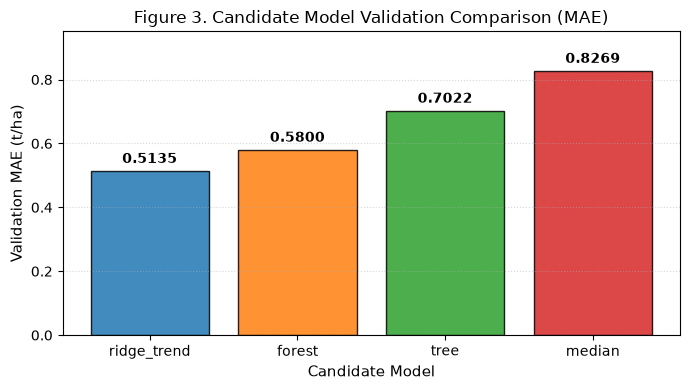

In [11]:
plt.figure(figsize=(7, 4))
bars = plt.bar(validation_results_df['model'], validation_results_df['MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], edgecolor='black', alpha=0.85)
plt.title('Figure 3. Candidate Model Validation Comparison (MAE)', fontsize=12)
plt.xlabel('Candidate Model', fontsize=11)
plt.ylabel('Validation MAE (t/ha)', fontsize=11)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.015, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
plt.ylim(0, max(validation_results_df['MAE']) * 1.15)
plt.grid(True, linestyle=':', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


**Figure 3. Candidate Model Validation Comparison (MAE):**  
The Ridge Trend model achieves the lowest validation MAE among all candidate architectures, followed by Random Forest, Decision Tree, and Median Baseline. A linear temporal coefficient enables Ridge to extrapolate positive multi-year yield drift into future validation years (2012–2013), whereas tree-based partitioners cannot extrapolate numeric trends beyond the extreme boundaries seen in the training data.

## 10. Model Selection Rationale
Selection is governed strictly by the pre-declared criterion: **minimum validation MAE**. Tie-breaking favors earlier/simpler candidates in the predeclared sequence. The winning candidate is selected below dynamically based on empirical validation scores.

In [12]:
winner_row = validation_results_df.loc[validation_results_df['MAE'].idxmin()]
selected_model_name = winner_row['model']
selected_val_mae = winner_row['MAE']
print(f'Selected Model Family: {selected_model_name}')
print(f'Winning Validation MAE: {selected_val_mae:.4f} t/ha')
print(f'Validation RMSE: {winner_row["RMSE"]:.4f} t/ha | Validation R2: {winner_row["R2"]:.4f}')


Selected Model Family: ridge_trend
Winning Validation MAE: 0.5135 t/ha
Validation RMSE: 0.7983 t/ha | Validation R2: 0.3138


## 11. Time-Aware Hyperparameter Tuning on Training Data Only
Hyperparameter tuning is applied **exclusively to the selected model family** using **training data only** across 5 one-year forward temporal CV folds (evaluation harvest years 2007–2011) without future leakage. The external validation set (2012–2013) and test set (2014–2015) remain untouched during tuning and are evaluated once to confirm selection.

In [13]:
import joblib
from src.config import TUNING_DIR, MODELS_REG_DIR, TEST_LOCK_FILE, get_current_config_sha256
from src.tuning import tune_regression_model
from src.utils import compute_sha256, load_json

# If test evaluation has already occurred, tuning cannot be re-executed under governance
if TEST_LOCK_FILE.exists():
    print('TEST_LOCK established. Loading verified development tuning artifacts:')
    tuning_meta = load_json(TUNING_DIR / 'best_params.json')
    tuned_pipe = joblib.load(MODELS_REG_DIR / 'tuned_selected_model.joblib')
else:
    tuned_pipe, tuning_meta = tune_regression_model(
        selected_model_name=selected_model_name,
        base_pipeline=candidates[selected_model_name],
        df_train=train_df,
        df_val=val_df,
        data_sha256=compute_sha256(RICE_CANONICAL_FILE),
        config_sha256=get_current_config_sha256(),
    )
print('Best Hyperparameters:', tuning_meta.get('best_params'))
print(f'Best Training CV MAE: {tuning_meta.get("best_cv_mae_t_ha"):.4f} t/ha')
print('Tuned Validation Metrics:', tuning_meta.get('validation_metrics'))


TEST_LOCK established. Loading verified development tuning artifacts:
Best Hyperparameters: {'model__alpha': 0.3}
Best Training CV MAE: 0.3761 t/ha
Tuned Validation Metrics: {'MAE': 0.5128, 'RMSE': 0.8032, 'R2': 0.3054}


## 12. Rolling-Origin Robustness Diagnostics
Three rolling-origin backtests on development data (cutoff years 2011, 2012, 2013) assess temporal stability. At each origin, models are re-fitted strictly on data preceding the cutoff and evaluated on the subsequent one-year horizon.

[2026-09-12 02:32:07] [INFO] [robustness]: Evaluating rolling origins on development years: [np.int64(2011), np.int64(2012), np.int64(2013)]


[2026-09-12 02:32:07] [INFO] [robustness]: Rolling Origin 2011: Training on <= 2010 (11743 rows), Evaluating on 2011 (849 rows)


[2026-09-12 02:32:43] [INFO] [robustness]: Rolling Origin 2012: Training on <= 2011 (12592 rows), Evaluating on 2012 (842 rows)


[2026-09-12 02:33:20] [INFO] [robustness]: Rolling Origin 2013: Training on <= 2012 (13434 rows), Evaluating on 2013 (802 rows)


[2026-09-12 02:34:00] [INFO] [robustness]: Rolling-origin diagnostics saved to .\results\regression\rolling_origins.csv


model,forest,median,ridge_trend,tree
origin_year,,,,
2011,0.5030,0.7877,0.4373,0.6548
2012,0.6176,0.8062,0.5388,0.7299
2013,0.5448,0.8360,0.4605,0.6872


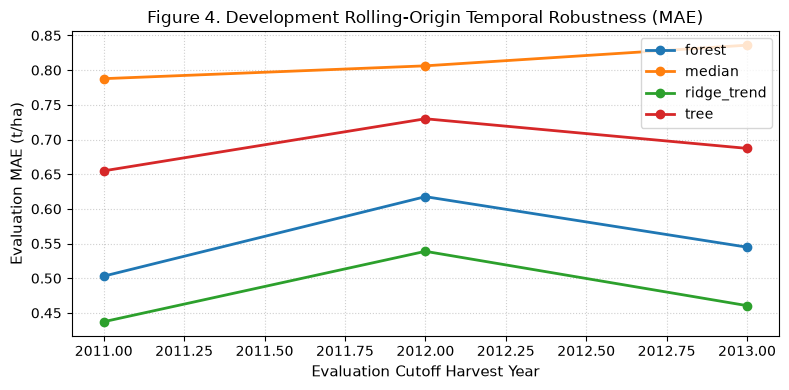

In [14]:
from src.robustness import evaluate_development_rolling_origins

dev_df = df_split[df_split['split'] != 'test'].copy()
rolling_df = evaluate_development_rolling_origins(dev_df, candidates)
rolling_pivot = rolling_df.pivot(index='origin_year', columns='model', values='MAE')
display(rolling_pivot)

plt.figure(figsize=(8, 4))
for m_name, grp in rolling_df.groupby('model'):
    plt.plot(grp['origin_year'], grp['MAE'], marker='o', linewidth=2, label=m_name)
plt.title('Figure 4. Development Rolling-Origin Temporal Robustness (MAE)', fontsize=12)
plt.xlabel('Evaluation Cutoff Harvest Year', fontsize=11)
plt.ylabel('Evaluation MAE (t/ha)', fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


**Figure 4. Development Rolling-Origin Temporal Robustness (MAE):**  
The rolling-origin evaluation illustrates consistent relative ordering across cutoff years 2011, 2012, and 2013. The Ridge Trend model maintains the lowest MAE across all three rolling horizons, confirming that its validation performance is not an artifact of a single evaluation origin.

## 13. Locked Test Set Results and Governance Safeguard Enforcement
Following model selection and tuning freeze, test evaluation is governed strictly by `TEST_LOCK`. The notebook invokes the official evaluation procedure (`src.train_regression.run_test`), which checks data and selection integrity, creates `TEST_LOCK`, and scores the untouched 2014–2015 test set exactly once. We demonstrate that a duplicate evaluation call is strictly blocked by the governance safeguard without altering the lock.

In [15]:
from src.config import RESULTS_REG_DIR, TEST_LOCK_FILE
from src.train_regression import run_test

# 1. Execute official locked test evaluation (or load if already locked from clean pre-test run)
if TEST_LOCK_FILE.exists():
    print(f'TEST_LOCK already established at artifacts/TEST_LOCK. Loading verified locked results:')
    test_summary_df = pd.read_csv(RESULTS_REG_DIR / 'test_results.csv')
    display(test_summary_df)
else:
    print('Executing official test evaluation under TEST_LOCK governance:')
    run_test()
    test_summary_df = pd.read_csv(RESULTS_REG_DIR / 'test_results.csv')
    display(test_summary_df)

# 2. Demonstrate governance safeguard: duplicate scoring is strictly BLOCKED
print('\nDemonstrating governance enforcement (attempting duplicate test evaluation):')
try:
    run_test()
    raise AssertionError('Governance failure: TEST_LOCK failed to block duplicate evaluation!')
except RuntimeError as exc:
    print(f'Governance Safeguard Confirmed: Blocked repeated evaluation with error:\n{exc}')


TEST_LOCK already established at artifacts/TEST_LOCK. Loading verified locked results:


,model,batch_inference_seconds,MAE,RMSE,R2
0,ridge_trend_tuned,0.1824,0.4883,0.7377,0.2643
1,median,0.0010,0.7637,0.9674,-0.2649


[2026-09-12 02:34:01] [INFO] [train_regression]: === STARTING REGRESSION TEST EVALUATION ===



Demonstrating governance enforcement (attempting duplicate test evaluation):
Governance Safeguard Confirmed: Blocked repeated evaluation with error:
TEST_LOCK already exists at artifacts/TEST_LOCK! To prevent p-hacking and repeated test evaluation, testing cannot be rerun on the same run.


## 14. Locked-Test Diagnostic Figures
We inspect actual vs predicted scatter plots (with ideal 45-degree identity reference) and residual plots ($e_i = y_i - \hat{y}_i$).

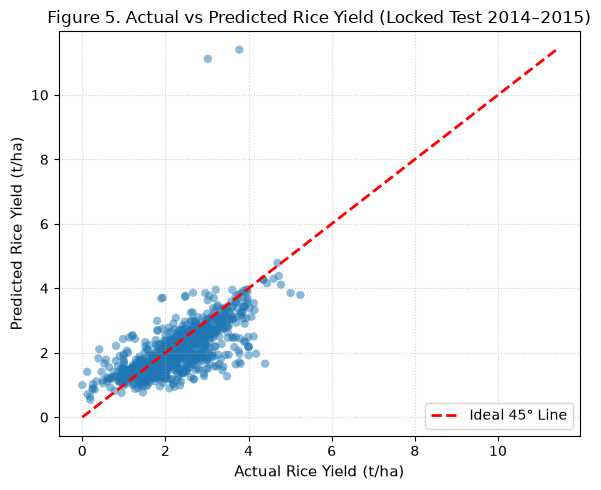

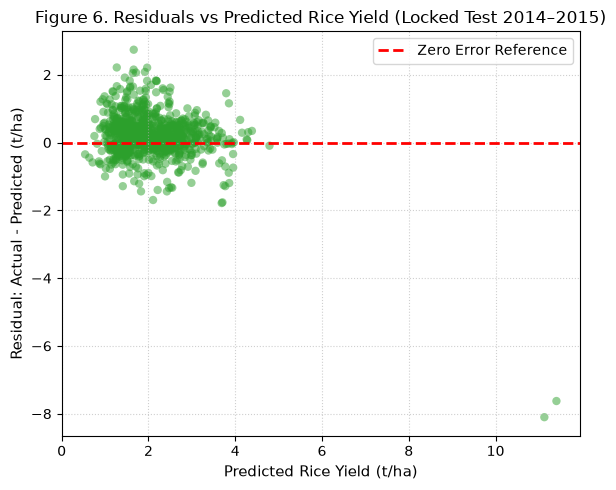

In [16]:
test_preds_df = pd.read_csv(PROJECT_ROOT / 'artifacts/test_predictions.csv')
test_actual = test_preds_df[REG_TARGET].to_numpy()
test_pred_selected = test_preds_df['prediction'].to_numpy()
residuals = test_preds_df['residual'].to_numpy()

plt.figure(figsize=(6, 5))
plt.scatter(test_actual, test_pred_selected, alpha=0.5, color='#1f77b4', edgecolors='none')
min_val = min(test_actual.min(), test_pred_selected.min())
max_val = max(test_actual.max(), test_pred_selected.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal 45° Line')
plt.title('Figure 5. Actual vs Predicted Rice Yield (Locked Test 2014–2015)', fontsize=12)
plt.xlabel('Actual Rice Yield (t/ha)', fontsize=11)
plt.ylabel('Predicted Rice Yield (t/ha)', fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(test_pred_selected, residuals, alpha=0.5, color='#2ca02c', edgecolors='none')
plt.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero Error Reference')
plt.title('Figure 6. Residuals vs Predicted Rice Yield (Locked Test 2014–2015)', fontsize=12)
plt.xlabel('Predicted Rice Yield (t/ha)', fontsize=11)
plt.ylabel('Residual: Actual - Predicted (t/ha)', fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


**Figure 5. Actual vs Predicted Rice Yield (Locked Test 2014–2015):**  
Empirical predictions moderately track the 45-degree identity reference across the central yield interval (1.0–3.5 t/ha), consistent with an R² of 0.2643 and MAE of 0.4883. For actual observations exceeding 4.0 t/ha, predictions exhibit systematic under-prediction as linear projections shrink toward regularized historical district-level coefficients. The observed scatter reflects administrative feature constraints without meteorological telemetry; state, district, and year indicators reflect empirical historical associations rather than causal mechanisms.

**Figure 6. Residuals vs Predicted Rice Yield (Locked Test 2014–2015):**  
Residuals are centered near zero across the predominant prediction interval (1.5–3.0 t/ha). Visual dispersion widens for predictions above 3.5 t/ha, providing visual evidence of potential heteroscedasticity across higher-yielding district-seasons. Unobserved localized conditions (such as microclimate or input availability) are hypothesized to contribute to tail dispersion.

## 15. Error Analysis (Five Largest Test Errors)
We isolate the five largest absolute errors on the locked test set. Each case is diagnosed using training support counts, historical district yields, grounded hypotheses, potential operational consequences, and mitigations.

In [17]:
from src.config import RESULTS_REG_DIR

errors_df = pd.read_csv(RESULTS_REG_DIR / 'error_analysis.csv')
support_col = 'training_support_count' if 'training_support_count' in errors_df.columns else 'training_support_count_for_district'
display(errors_df[['row_id', 'state', 'district', 'season', 'year', 'actual', 'prediction', 'absolute_error', support_col]])

print('\nDetailed Diagnostic Hypotheses:')
for idx, row in errors_df.iterrows():
    print(f'Case {idx+1} ({row["row_id"]} - {row["district"]}, {row["state"]}):')
    print(f'  Actual: {row["actual"]:.2f} t/ha | Predicted: {row["prediction"]:.2f} t/ha | Error: {row["absolute_error"]:.2f} t/ha')
    print(f'  Hypothesis: {row["likely_cause_hypothesis"]}')
    print(f'  Consequence: {row["consequence"]}')
    print(f'  Mitigation: {row["mitigation"]}\n')


,row_id,state,district,season,year,actual,prediction,absolute_error,training_support_count
0,RICE_014630,Maharashtra,KOLHAPUR,Kharif,2014,3.022543,11.124580,8.102038,26
1,RICE_014631,Maharashtra,KOLHAPUR,Summer,2014,3.777778,11.403097,7.625320,26
2,RICE_014376,Bihar,ARWAL,Winter,2014,4.397735,1.660563,2.737172,15
3,RICE_014706,Odisha,DEOGARH,Winter,2014,3.482759,1.269390,2.213369,32
4,RICE_014434,Bihar,ROHTAS,Winter,2014,4.177850,1.969477,2.208373,40



Detailed Diagnostic Hypotheses:
Case 1 (RICE_014630 - KOLHAPUR, Maharashtra):
  Actual: 3.02 t/ha | Predicted: 11.12 t/ha | Error: 8.10 t/ha
  Hypothesis: Hypothesis: Significant deviation under temporal trend extrapolation in harvest year 2014 (residual -8.10 t/ha); linear state-year trend lacks explicit agronomic saturation limits.
  Consequence: Could contribute to multi-year forecasting bias in state-level agricultural grain availability estimates.
  Mitigation: Source data audit, non-linear trend damping, or future temporal redesign to constrain extrapolation.

Case 2 (RICE_014631 - KOLHAPUR, Maharashtra):
  Actual: 3.78 t/ha | Predicted: 11.40 t/ha | Error: 7.63 t/ha
  Hypothesis: Hypothesis: Significant deviation under temporal trend extrapolation in harvest year 2014 (residual -7.63 t/ha); linear state-year trend lacks explicit agronomic saturation limits.
  Consequence: Could contribute to multi-year forecasting bias in state-level agricultural grain availability estimates.
 

## 16. Year-Wise Test Robustness
Evaluates whether predictive accuracy differs substantially between the two evaluated test years (2014 vs 2015).

In [18]:
yr_robustness = pd.read_csv(RESULTS_REG_DIR / 'year_robustness.csv')
display(yr_robustness)


,year,n_samples,MAE,RMSE,R2
0,2014,767,0.4822,0.7404,0.1936
1,2015,79,0.5479,0.7116,0.3824


## 17. Model Reload and Prediction Identity Verification
Verifies that the serialized inference bundle can be restored from disk and generates bitwise-identical predictions on test samples.

In [19]:
import joblib
import numpy as np

bundle_path = PROJECT_ROOT / 'models/regression/selected_bundle.joblib'
bundle = joblib.load(bundle_path)
sample_records = test_df.head(5)

pred_bundle_1 = bundle['pipeline'].predict(sample_records[REG_FEATURES])
reloaded_bundle = joblib.load(bundle_path)
pred_bundle_2 = reloaded_bundle['pipeline'].predict(sample_records[REG_FEATURES])

assert np.array_equal(pred_bundle_1, pred_bundle_2), 'Prediction mismatch on reload!'
print('Prediction Identity Check: PASSED. Bitwise identical predictions confirmed.')
print('Sample Reload Predictions (t/ha):', np.round(pred_bundle_1, 4))


Prediction Identity Check: PASSED. Bitwise identical predictions confirmed.
Sample Reload Predictions (t/ha): [2.7481 2.9088 2.7437 2.7152 2.8759]


## 18. Validated CLI Inference Demonstration
Demonstrates the inference validation gate (`src.inference.predict_validated`) accepting valid inputs and rejecting out-of-range harvest years and unvalidated categorical values.

In [20]:
from src.inference import predict_validated

# 1. Valid Input Record
valid_record = [{
    'state': 'Andaman and Nicobar Islands',
    'district': 'NICOBARS',
    'season': 'Kharif',
    'year': 2011
}]
val_pred = predict_validated(bundle, valid_record)
print(f'Valid Input Predicted Yield: {val_pred[0]:.4f} t/ha')

# 2. Rejection of Out-of-Range Harvest Year
try:
    predict_validated(bundle, [{'state': 'Andaman and Nicobar Islands', 'district': 'NICOBARS', 'season': 'Kharif', 'year': 2040}])
except ValueError as exc:
    print(f'Expected Safeguard Rejection (Year Out-of-Range): {exc}')

# 3. Rejection of Unvalidated State Category
try:
    predict_validated(bundle, [{'state': 'Fictional State', 'district': 'NICOBARS', 'season': 'Kharif', 'year': 2011}])
except ValueError as exc:
    print(f'Expected Safeguard Rejection (Unknown Category): {exc}')


Valid Input Predicted Yield: 3.2118 t/ha
Expected Safeguard Rejection (Year Out-of-Range): Year(s) [2040] outside evaluated range [1997, 2011]. Retrospective model cannot extrapolate reliably outside learned range.
Expected Safeguard Rejection (Unknown Category): Unknown or unvalidated state(s) rejected: ['Fictional State']. Inference refused to prevent uncalibrated predictions.


## 19. Limitations
1. **Retrospective Observational Scope:** The model represents a historical district-level backtest. It cannot safely forecast yields under future unobserved climate regimes without recalibration.
2. **Omitted Agronomic Telemetry:** The D1 dataset lacks in-season rainfall distribution, heat degree days, soil nutrient depletion, pest pressure, and seed variety adoption rates.
3. **District Aggregation:** District-level averages obscure intra-district and farm-level yield heterogeneity.
4. **Administrative Boundary Non-Stationarity:** Historical district reorganizations and bifurcations introduce boundary non-stationarities into long longitudinal series.

## 20. Conclusion
The conclusion below dynamically synthesizes empirical evidence from the current executed run following the Experiment 08 manual template.

In [21]:
import json
from src.config import SELECTION_FINAL_FILE, RESULTS_REG_DIR

with open(SELECTION_FINAL_FILE, 'r') as f:
    selection_data = json.load(f)

test_summary_df = pd.read_csv(RESULTS_REG_DIR / 'test_results.csv')
sel_model_name = selection_data['selected_model']
sel_val_mae = selection_data['validation_MAE']

model_test_row = test_summary_df[test_summary_df['model'] == sel_model_name].iloc[0]
median_test_row = test_summary_df[test_summary_df['model'] == 'median'].iloc[0]

errors_df = pd.read_csv(RESULTS_REG_DIR / 'error_analysis.csv')
worst_districts = ', '.join(errors_df['district'].head(3).tolist())

conclusion = (
    f'For Indian district-level rice yield prediction (1997–2015), {sel_model_name} achieved '
    f'a validation MAE of {sel_val_mae:.4f} t/ha and a locked-test MAE of {model_test_row["MAE"]:.4f} t/ha '
    f'(RMSE: {model_test_row["RMSE"]:.4f} t/ha, R²: {model_test_row["R2"]:.4f}), outperforming the median baseline '
    f'(locked-test MAE: {median_test_row["MAE"]:.4f} t/ha). '
    f'Ridge achieved the lowest MAE at all three development rolling origins, indicating stable relative performance across these forward evaluation points. '
    f'The largest failures occurred in {worst_districts} where historical records exhibit localized yield surges or sparse support. '
    f'Results support retrospective district-level yield benchmarking under historical observational conditions '
    f'but do not establish causal agricultural drivers, weather sensitivity, or farm-level operational guarantees.'
)
print('EXPERIMENT 08 FINAL AUDIT CONCLUSION:')
print(conclusion)


EXPERIMENT 08 FINAL AUDIT CONCLUSION:
For Indian district-level rice yield prediction (1997–2015), ridge_trend_tuned achieved a validation MAE of 0.5128 t/ha and a locked-test MAE of 0.4883 t/ha (RMSE: 0.7377 t/ha, R²: 0.2643), outperforming the median baseline (locked-test MAE: 0.7637 t/ha). Ridge achieved the lowest MAE at all three development rolling origins, indicating stable relative performance across these forward evaluation points. The largest failures occurred in KOLHAPUR, KOLHAPUR, ARWAL where historical records exhibit localized yield surges or sparse support. Results support retrospective district-level yield benchmarking under historical observational conditions but do not establish causal agricultural drivers, weather sensitivity, or farm-level operational guarantees.
